# Verify augmented datasets — P1 membership and pixel bounds

Loads the single-x₀ augmented datasets generated by:
```
python scripts/build_augmented_dataset.py --model_type mlp --strategy walk \
    --walk_mode projected --nb_aug_points 200 --max_steps 20000 \
    --p1_filter_tol 1e-4 --nb_diverse 50 \
    --n_samples 1 --seed 42

python scripts/build_augmented_dataset.py --model_type cnn --strategy walk \
    --walk_mode projected --nb_aug_points 200 --max_steps 20000 \
    --p1_filter_tol 1e-4 --nb_diverse 50 \
    --n_samples 1 --seed 42
```

For each dataset, checks:
1. All augmented points are within pixel bounds `[-1, +1]`
2. All augmented points satisfy the P1 constraints `A·x + b ≤ 0`
3. Summary statistics: distances from x₀, constraint violation distribution

In [11]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


In [12]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.models.networks           import FashionMLP_Large, FashionCNN_Small
from src.quantization.quantize     import quantize_model
from src.optim.build_polytopes     import build_all_polytopes
from src.optim.build_polytopes_cnn import build_cnn_all_polytopes

BITS       = 4
SAMPLE_IDX = 0      # same x₀ that was used to generate the datasets
PIX_TOL    = 1e-6   # tolerance for pixel-bounds check
P1_TOL     = 1e-4   # tolerance for P1 membership check (matches --p1_filter_tol)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Device:", device)

Device: mps


## Helper — load model + P1 constraints for one model type

In [13]:
def load_resources(model_type):
    """Return (x0_flat_np, A_np, b_np, label_c, x0_tensor) for model_type."""
    # --- model ---
    if model_type == "cnn":
        model = FashionCNN_Small()
    else:
        model = FashionMLP_Large()
    ckpt = ROOT / f"checkpoints/fashion_{model_type}_best.pth"
    model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
    model.eval().to(device)

    qmodel = quantize_model(model, bits=BITS)
    qmodel.eval()

    # --- sample x₀ ---
    correct_path = ROOT / f"data/fashionMNIST_correct_{model_type}.pt"
    dataset = torch.load(correct_path, weights_only=False)
    x_raw, c = dataset[SAMPLE_IDX]
    c = int(c)

    # --- build P1 ---
    if model_type == "cnn":
        x_batch = x_raw.unsqueeze(0).to(device)
        x0      = x_raw.unsqueeze(0).to(device)
        A, b, _ = build_cnn_all_polytopes(model, {BITS: qmodel}, x_batch, c)
    else:
        x_batch = x_raw.flatten().unsqueeze(0).to(device)
        x0      = x_raw.flatten().unsqueeze(0).to(device)
        A, b, _ = build_all_polytopes(model, {BITS: qmodel}, x_batch, c)

    A_np = A.detach().cpu().numpy()
    b_np = b.detach().cpu().numpy()
    x0_flat = x0.detach().cpu().numpy().reshape(-1)

    n_at_lo = np.sum(np.isclose(x0_flat, -1.0, atol=1e-6))
    n_at_hi = np.sum(np.isclose(x0_flat,  1.0, atol=1e-6))
    print(f"[{model_type.upper()}] x₀ pixels at -1: {n_at_lo}/784  at +1: {n_at_hi}/784  "
          f"interior: {784-n_at_lo-n_at_hi}/784")
    print(f"[{model_type.upper()}] P1 constraints : {A_np.shape[0]}  "
          f"(A shape {A_np.shape})")

    return x0_flat, A_np, b_np, c, x0

In [14]:
resources = {}
for mt in ["mlp", "cnn"]:
    resources[mt] = load_resources(mt)
    print()

[MLP] x₀ pixels at -1: 351/784  at +1: 4/784  interior: 429/784
[MLP] P1 constraints : 1929  (A shape (1929, 784))

[CNN] x₀ pixels at -1: 351/784  at +1: 4/784  interior: 429/784
[CNN] P1 constraints : 20685  (A shape (20685, 784))



## Load augmented datasets

In [15]:
aug_datasets = {}
for mt in ["mlp", "cnn"]:
    path = ROOT / f"data/fashionMNIST_augmented_{mt}_seed42_walk.pt"
    if not path.exists():
        print(f"[{mt.upper()}] Dataset not found: {path}")
        print(f"  Run: python scripts/build_augmented_dataset.py --model_type {mt} "
              f"--strategy walk --walk_mode projected --nb_aug_points 50 "
              f"--max_steps 10000 --p1_filter_tol 1e-4 --n_samples 1 --seed 42")
        aug_datasets[mt] = None
    else:
        data = torch.load(path, weights_only=False)
        aug_datasets[mt] = data
        print(f"[{mt.upper()}] Loaded {len(data)} augmented points from {path.name}")

[MLP] Loaded 50 augmented points from fashionMNIST_augmented_mlp_seed42_walk.pt
[CNN] Loaded 50 augmented points from fashionMNIST_augmented_cnn_seed42_walk.pt


## Verification — pixel bounds and P1 membership

In [16]:
for mt in ["mlp", "cnn"]:
    data = aug_datasets[mt]
    if data is None:
        continue

    x0_flat, A_np, b_np, c, _ = resources[mt]
    n = len(data)

    # Stack all augmented points: (n, 784)
    pts = np.stack([x.detach().cpu().numpy().reshape(-1) for x, _ in data], axis=0)

    # ── 1. Pixel bounds ────────────────────────────────────────────────────────
    pmin, pmax = pts.min(), pts.max()
    out_pix = np.any((pts < -1.0 - PIX_TOL) | (pts > 1.0 + PIX_TOL), axis=1)
    n_pix_fail = out_pix.sum()

    # ── 2. P1 membership ───────────────────────────────────────────────────────
    # A_np @ pts.T + b_np[:, None]  shape (m, n)
    cv = A_np @ pts.T + b_np[:, None]   # (m, n)
    worst = cv.max(axis=0)              # (n,) worst constraint per point
    n_p1_fail = (worst > P1_TOL).sum()
    max_viol  = worst.max()
    mean_viol = worst.mean()

    # ── 3. Distance from x₀ ───────────────────────────────────────────────────
    diffs = np.abs(pts - x0_flat)       # (n, 784)
    linf  = diffs.max(axis=1)           # (n,) per-point L∞
    l1    = diffs.mean(axis=1)          # (n,) per-point mean |Δpixel|

    # ── Report ─────────────────────────────────────────────────────────────────
    pix_status = "OK" if n_pix_fail == 0 else f"FAIL ({n_pix_fail}/{n} outside)"
    p1_status  = "OK" if n_p1_fail  == 0 else f"FAIL ({n_p1_fail}/{n} outside)"

    print(f"{'='*55}")
    print(f"  Model : {mt.upper()}   ({n} augmented points)")
    print(f"{'='*55}")
    print(f"  Pixel bounds [-1,+1]  : {pix_status}")
    print(f"    pixel range         : [{pmin:+.6f}, {pmax:+.6f}]")
    print()
    print(f"  P1 membership (tol={P1_TOL:.0e}) : {p1_status}")
    print(f"    max  constraint viol : {max_viol:+.4e}")
    print(f"    mean constraint viol : {mean_viol:+.4e}")
    print(f"    (negative = strictly inside P1)")
    print()
    print(f"  Distance from x₀")
    print(f"    L∞  mean / max       : {linf.mean():.4f} / {linf.max():.4f}")
    print(f"    mean|Δpixel| mean/max: {l1.mean():.4f} / {l1.max():.4f}")
    print()

  Model : MLP   (50 augmented points)
  Pixel bounds [-1,+1]  : OK
    pixel range         : [-1.000000, +1.000000]

  P1 membership (tol=1e-04) : OK
    max  constraint viol : +5.2180e-05
    mean constraint viol : -7.9595e-03
    (negative = strictly inside P1)

  Distance from x₀
    L∞  mean / max       : 0.5584 / 0.7793
    mean|Δpixel| mean/max: 0.1299 / 0.1846

  Model : CNN   (50 augmented points)
  Pixel bounds [-1,+1]  : OK
    pixel range         : [-1.000000, +1.000000]

  P1 membership (tol=1e-04) : OK
    max  constraint viol : +1.3039e-06
    mean constraint viol : +9.6040e-07
    (negative = strictly inside P1)

  Distance from x₀
    L∞  mean / max       : 0.0000 / 0.0000
    mean|Δpixel| mean/max: 0.0000 / 0.0000



## Distribution of P1 constraint violations

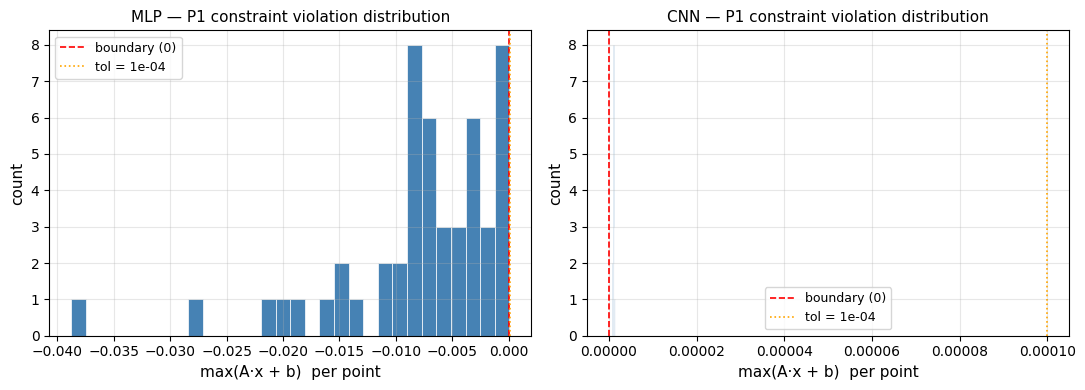

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, mt in zip(axes, ["mlp", "cnn"]):
    data = aug_datasets[mt]
    if data is None:
        ax.set_title(f"{mt.upper()} — dataset missing")
        continue

    _, A_np, b_np, _, _ = resources[mt]
    pts = np.stack([x.detach().cpu().numpy().reshape(-1) for x, _ in data], axis=0)
    worst = (A_np @ pts.T + b_np[:, None]).max(axis=0)   # (n,)

    ax.hist(worst, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.axvline(0,       color="red",    linestyle="--", linewidth=1.2, label="boundary (0)")
    ax.axvline(P1_TOL,  color="orange", linestyle=":",  linewidth=1.2, label=f"tol = {P1_TOL:.0e}")
    ax.set_xlabel("max(A·x + b)  per point", fontsize=11)
    ax.set_ylabel("count", fontsize=11)
    ax.set_title(f"{mt.upper()} — P1 constraint violation distribution", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Distribution of distances from x₀

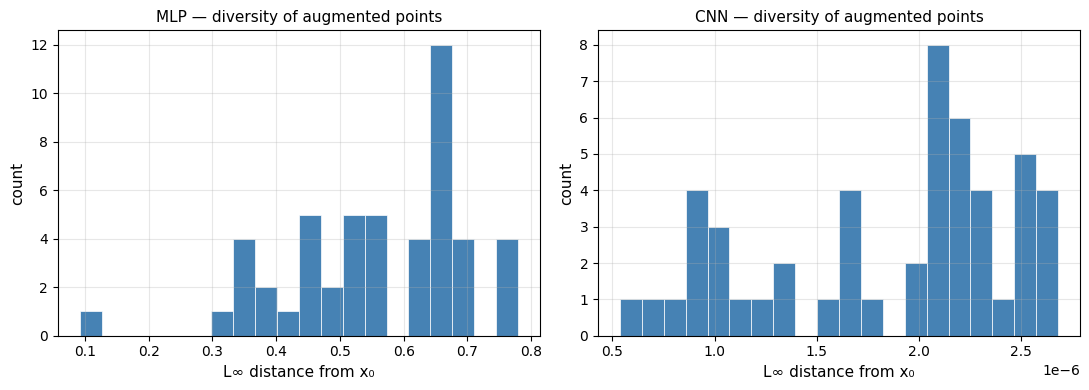

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, mt in zip(axes, ["mlp", "cnn"]):
    data = aug_datasets[mt]
    if data is None:
        ax.set_title(f"{mt.upper()} — dataset missing")
        continue

    x0_flat = resources[mt][0]
    pts = np.stack([x.detach().cpu().numpy().reshape(-1) for x, _ in data], axis=0)
    linf = np.abs(pts - x0_flat).max(axis=1)

    ax.hist(linf, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("L∞ distance from x₀", fontsize=11)
    ax.set_ylabel("count", fontsize=11)
    ax.set_title(f"{mt.upper()} — diversity of augmented points", fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visual grid — 50 augmented images (5 rows × 10 columns)

/var/folders/jj/mflbhpsx5fn9czwyvl39hk_r0000gn/T/ipykernel_52186/813417243.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


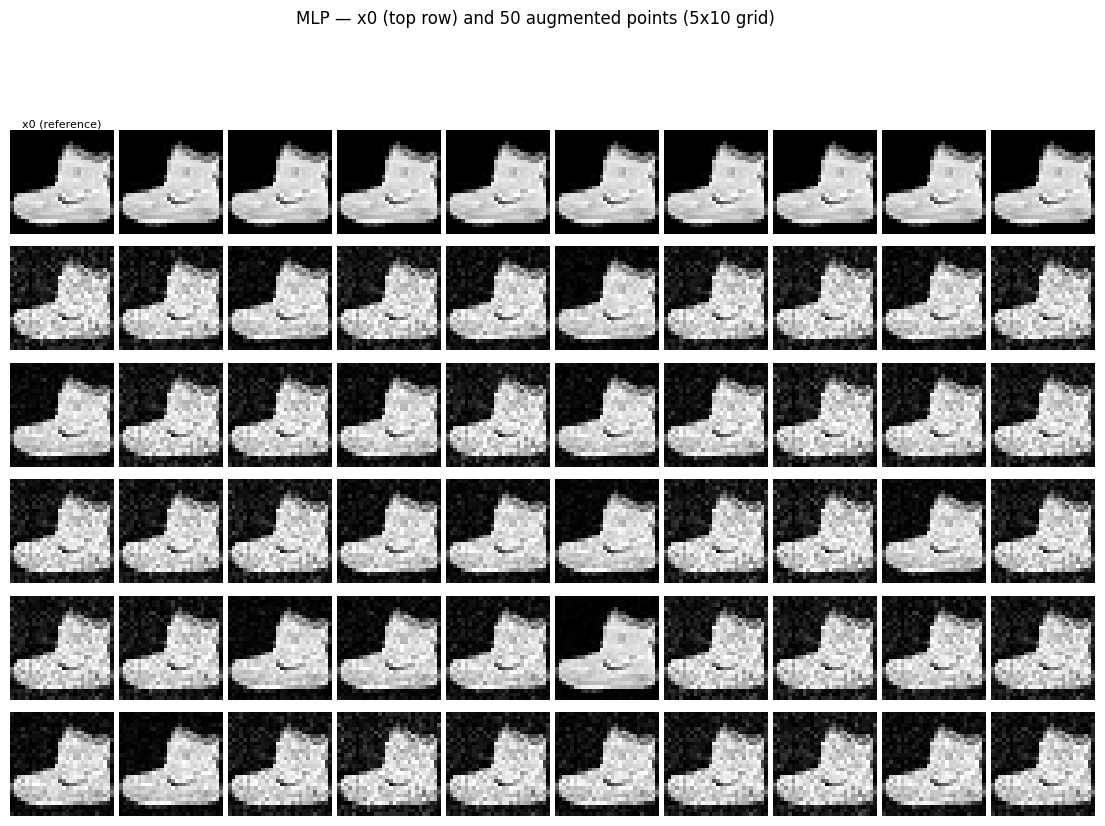

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/aug_grid_mlp.pdf


/var/folders/jj/mflbhpsx5fn9czwyvl39hk_r0000gn/T/ipykernel_52186/813417243.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


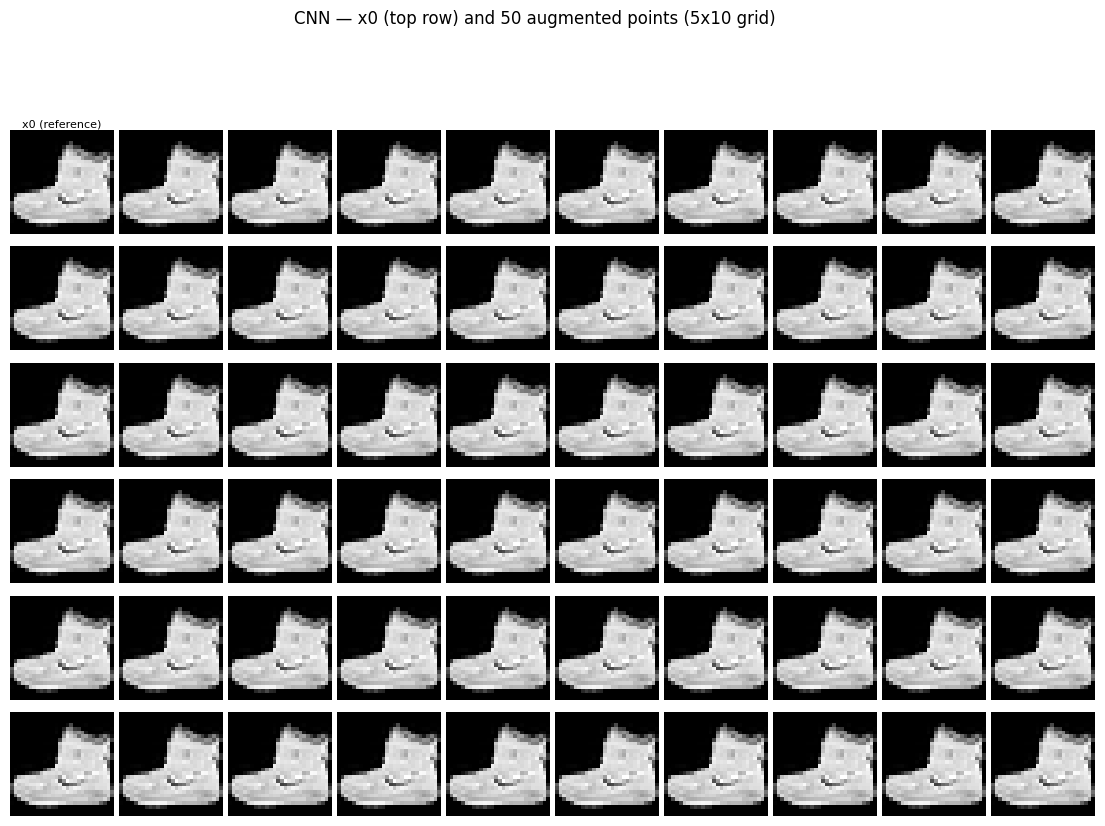

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/aug_grid_cnn.pdf


In [19]:
def plot_aug_grid(model_type, data, x0_flat, n_rows=5, n_cols=10):
    """Plot x0 (top row, repeated) then n_rows*n_cols augmented images."""
    n_show = n_rows * n_cols
    n      = min(len(data), n_show)

    def to_img(arr_flat):
        return ((arr_flat.reshape(28, 28) + 1.0) / 2.0).clip(0, 1)

    fig, axes = plt.subplots(
        n_rows + 1, n_cols,
        figsize=(n_cols * 1.4, (n_rows + 1) * 1.5),
        gridspec_kw={"hspace": 0.05, "wspace": 0.05},
    )

    # Row 0: x0 repeated across all columns (reference)
    x0_img = to_img(x0_flat)
    for col in range(n_cols):
        axes[0, col].imshow(x0_img, cmap="gray", vmin=0, vmax=1)
        axes[0, col].axis("off")
    axes[0, 0].set_title("x0 (reference)", fontsize=8, pad=2)

    # Rows 1..n_rows: augmented points
    for idx in range(n_show):
        row = idx // n_cols + 1
        col = idx  % n_cols
        ax  = axes[row, col]
        if idx < n:
            x_aug, _ = data[idx]
            ax.imshow(to_img(x_aug.detach().cpu().numpy().reshape(-1)), cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(np.ones((28, 28)), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

    fig.suptitle(
        f"{model_type.upper()} — x0 (top row) and {n} augmented points ({n_rows}x{n_cols} grid)",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    out = ROOT / f"results/aug_grid_{model_type}.pdf"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved to {out}")


for mt in ["mlp", "cnn"]:
    data = aug_datasets[mt]
    if data is None:
        print(f"[{mt.upper()}] dataset missing -- skipping")
        continue
    x0_flat = resources[mt][0]
    plot_aug_grid(mt, data, x0_flat)
